<a href="https://colab.research.google.com/github/SakshiKore03/DS-Projects/blob/main/MovieRecommendation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas numpy scikit-learn

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
import pandas as pd

df = pd.read_csv("IMDb Movies India.csv", encoding='latin1')
print(df.head())
print(df.columns)

                                 Name    Year Duration            Genre  \
0                                         NaN      NaN            Drama   
1  #Gadhvi (He thought he was Gandhi)  (2019)  109 min            Drama   
2                         #Homecoming  (2021)   90 min   Drama, Musical   
3                             #Yaaram  (2019)  110 min  Comedy, Romance   
4                   ...And Once Again  (2010)  105 min            Drama   

   Rating Votes            Director       Actor 1             Actor 2  \
0     NaN   NaN       J.S. Randhawa      Manmauji              Birbal   
1     7.0     8       Gaurav Bakshi  Rasika Dugal      Vivek Ghamande   
2     NaN   NaN  Soumyajit Majumdar  Sayani Gupta   Plabita Borthakur   
3     4.4    35          Ovais Khan       Prateik          Ishita Raj   
4     NaN   NaN        Amol Palekar  Rajat Kapoor  Rituparna Sengupta   

           Actor 3  
0  Rajendra Bhatia  
1    Arvind Jangid  
2       Roy Angana  
3  Siddhant Kapoor  
4    

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB
None


In [ ]:
df.fillna('', inplace=True)


/tmp/ipykernel_875/3531994057.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.fillna('', inplace=True)


In [ ]:
df['combined_features'] = (
    df['Genre'] + ' ' +
    df['Director'] + ' ' +
    df['Actor 1'] + ' ' +
    df['Actor 2'] + ' ' +
    df['Actor 3']
)

print(df[['Name', 'combined_features']].head())

                                 Name  \
0                                       
1  #Gadhvi (He thought he was Gandhi)   
2                         #Homecoming   
3                             #Yaaram   
4                   ...And Once Again   

                                   combined_features  
0  Drama J.S. Randhawa Manmauji Birbal Rajendra B...  
1  Drama Gaurav Bakshi Rasika Dugal Vivek Ghamand...  
2  Drama, Musical Soumyajit Majumdar Sayani Gupta...  
3  Comedy, Romance Ovais Khan Prateik Ishita Raj ...  
4  Drama Amol Palekar Rajat Kapoor Rituparna Seng...  


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
cv = CountVectorizer(stop_words='english')
count_matrix = cv.fit_transform(df['combined_features'])

In [ ]:
similarity = cosine_similarity(count_matrix)

In [ ]:
def recommend(movie_name):

    movie_name = movie_name.lower()

    titles = df['Name'].str.lower()

    if movie_name not in titles.values:
        print("Movie not found!")
        return

    index = titles[titles == movie_name].index[0]

    similarity_scores = list(enumerate(similarity[index]))

    sorted_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    print("Recommended Movies:\n")

    count = 0

    for i in sorted_scores[1:]:
        title = df.iloc[i[0]]['Name']
        print(title)
        count += 1

        if count == 5:
            break

In [ ]:
recommend("Sholay")

Recommended Movies:

Seeta Aur Geeta
Shaan
Shakti
Mr. Natwarlal
Immaan Dharam


In [ ]:
recommend("Dangal")

Recommended Movies:

Ghajini
Badla
Thokar
Like Stars on Earth
Isi Ka Naam Zindagi


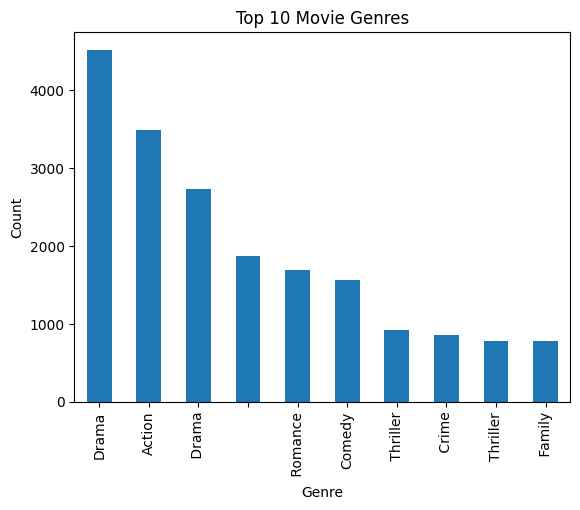

In [ ]:
import matplotlib.pyplot as plt

genres = df['Genre'].str.split(',').explode()

genres.value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Movie Genres")
plt.xlabel("Genre")
plt.ylabel("Count")

plt.show()

In [ ]:
print("Movie Recommendation System Completed Successfully")

Movie Recommendation System Completed Successfully


In [ ]:
recommend("dangal")

Recommended Movies:

Ghajini
Badla
Thokar
Like Stars on Earth
Isi Ka Naam Zindagi


In [ ]:
!pip install fuzzywuzzy python-Levenshtein

  Using cached fuzzywuzzy-0.18.0-py2.py3-none-any.whl.metadata (4.9 kB)
  Using cached python_levenshtein-0.27.3-py3-none-any.whl.metadata (3.9 kB)
  Using cached levenshtein-0.27.3-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (3.7 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 33.4 MB/s eta 0:00:00


In [ ]:
from fuzzywuzzy import process

def recommend_fuzzy(movie_name):
    match = process.extractOne(movie_name, df['Name'])

    if match:
        print("Closest Match:", match[0])
        recommend(match[0])

In [ ]:
recommend_fuzzy("shol")

Closest Match: Aag Aur Shola
Recommended Movies:

Himmat Aur Mehanat
Mawaali
Ghar Sansar
Badla
Bhunsaara


In [ ]:
def recommend(movie_name):

    movie_name = movie_name.lower()
    titles = df['Name'].str.lower()

    if movie_name not in titles.values:
        print("Movie not found!")
        return

    index = titles[titles == movie_name].index[0]

    similarity_scores = list(enumerate(similarity[index]))

    sorted_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    print("\n🎬 Recommended Movies:\n")

    count = 0

    for i in sorted_scores[1:]:

        print("🎬 Movie:", df.iloc[i[0]]['Name'])
        print("⭐ Rating:", df.iloc[i[0]]['Rating'])
        print("🎥 Director:", df.iloc[i[0]]['Director'])
        print("--------------------------")

        count += 1

        if count == 5:
            break

In [ ]:
recommend("Sholay")


🎬 Recommended Movies:

🎬 Movie: Seeta Aur Geeta
⭐ Rating: 6.8
🎥 Director: Ramesh Sippy
--------------------------
🎬 Movie: Shaan
⭐ Rating: 7.1
🎥 Director: Ramesh Sippy
--------------------------
🎬 Movie: Shakti
⭐ Rating: 7.7
🎥 Director: Ramesh Sippy
--------------------------
🎬 Movie: Mr. Natwarlal
⭐ Rating: 6.6
🎥 Director: Rakesh Kumar
--------------------------
🎬 Movie: Immaan Dharam
⭐ Rating: 5.7
🎥 Director: Desh Mukherjee
--------------------------
